In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

In [14]:
def initialisation(dimensions):
    parametres = {}
    C = len(dimensions)
    np.random.seed(1)
    for c in range(1, C):
        parametres['W' + str(c)] = np.random.randn(dimensions[c], dimensions[c - 1]) * 0.01
        parametres['b' + str(c)] = np.zeros((dimensions[c], 1))
    return parametres

In [33]:
parameters = initialisation([64, 32, 16, 3])
print(f'W1 shape: {parameters["W1"].shape}, b1 shape: {parameters["b1"].shape}')

W1 shape: (32, 64), b1 shape: (32, 1)


In [15]:
def forward_propagation(X, parametres):
    activations = {'A0': X}
    C = len(parametres) // 2
    for c in range(1, C + 1):
        Z = parametres['W' + str(c)].dot(activations['A' + str(c - 1)]) + parametres['b' + str(c)]
        activations['A' + str(c)] = np.maximum(0, Z)
    return activations

In [34]:
activations = forward_propagation(np.random.rand(64, 10), parameters)
print(f'A1 shape: {activations["A1"].shape}, A2 shape: {activations["A2"].shape}, A3 shape: {activations["A3"].shape}')

A1 shape: (32, 10), A2 shape: (16, 10), A3 shape: (3, 10)


In [16]:
def back_propagation(y, parametres, activations):
    m = y.shape[1]
    C = len(parametres) // 2
    gradients = {}
    dA = activations['A' + str(C)] - y
    dZ = dA * (activations['A' + str(C)] > 0)
    for c in reversed(range(1, C + 1)):
        gradients['dW' + str(c)] = (1 / m) * np.dot(dZ, activations['A' + str(c - 1)].T)
        gradients['db' + str(c)] = (1 / m) * np.sum(dZ, axis=1, keepdims=True)
        if c > 1:
            dA_prev = np.dot(parametres['W' + str(c)].T, dZ)
            dZ = dA_prev * (activations['A' + str(c - 1)] > 0)
    return gradients

In [36]:
gradients = back_propagation(np.random.rand(3, 10), parameters, activations)
print(f'dW1 shape: {gradients["dW1"].shape}')
print(f'db1 shape: {gradients["db1"].shape}')   
print(f'dW2 shape: {gradients["dW2"].shape}')
print(f'db2 shape: {gradients["db2"].shape}')
print(f'dW3 shape: {gradients["dW3"].shape}')
print(f'db3 shape: {gradients["db3"].shape}')


dW1 shape: (32, 64)
db1 shape: (32, 1)
dW2 shape: (16, 32)
db2 shape: (16, 1)
dW3 shape: (3, 16)
db3 shape: (3, 1)


In [ ]:
def update(gradients, parametres, learning_rate):
    C = len(parametres) // 2
    for c in range(1, C + 1):
        parametres['W' + str(c)] -= learning_rate * gradients['dW' + str(c)]
        parametres['b' + str(c)] -= learning_rate * gradients['db' + str(c)]
    return parametres

In [38]:
parameters = update(gradients, parameters, learning_rate=0.01)
print(f'Updated W1 shape: {parameters["W1"].shape}, Updated b1 shape: {parameters["b1"].shape}')
print(f'Updated W2 shape: {parameters["W2"].shape}, Updated b2 shape: {parameters["b2"].shape}')
print(f'Updated W3 shape: {parameters["W3"].shape}, Updated b3 shape: {parameters["b3"].shape}')

Updated W1 shape: (32, 64), Updated b1 shape: (32, 1)
Updated W2 shape: (16, 32), Updated b2 shape: (16, 1)
Updated W3 shape: (3, 16), Updated b3 shape: (3, 1)


In [ ]:
def predict(X, parametres):
    activations = forward_propagation(X, parametres)
    C = len(parametres) // 2
    Af = activations['A' + str(C)] 
    return np.argmax(Af, axis=0) 

In [ ]:
def deep_neural_network(X, y_onehot, y_labels,hidden_layers,learning_rate,n_iter):
    number_of_classes = y_onehot.shape[0]
    dimensions = [X.shape[0]] + list(hidden_layers) + [number_of_classes]
    parametres = initialisation(dimensions)
    training_history = np.zeros((n_iter, 2))  
    C = len(parametres) // 2

    for i in range(n_iter):
        activations = forward_propagation(X, parametres)
        gradients   = back_propagation(y_onehot, parametres, activations)
        parametres  = update(gradients, parametres, learning_rate)
        Af = activations['A' + str(C)]  
        eps = 1e-15
        loss = -np.mean(np.sum(y_onehot * np.log(Af + eps), axis=0))
        training_history[i, 0] = loss
        y_pred = np.argmax(Af, axis=0)
        training_history[i, 1] = accuracy_score(y_labels, y_pred)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(training_history[:, 0], label='Train Loss', color='red' , linewidth=2)
    plt.title('Cross-Entropie loss')
    plt.xlabel('Itérations')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(training_history[:, 1], label='Train Accuracy', color='blue', linewidth=2)
    plt.title('Classification Accuracy')
    plt.xlabel('Itérations')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return parametres, training_history

size of the dataset  : (150, 1024)


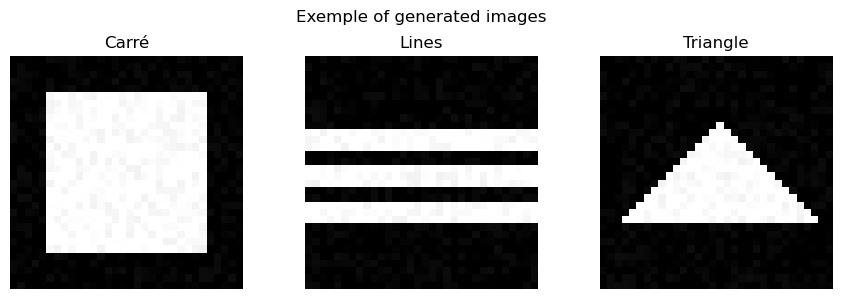

In [39]:
# classe 0 = square
# classe 1 = Lines
# classe 2 = triangle

Image_size     = 32
Number_of_image_per_classe  = 50  
white_add   = 0.05 
black_add   = 0.05 
np.random.seed(42)


def add_intansities(image, bruit_blanc=0.07, bruit_noir=0.06):
    noisy = image.copy().astype(float)
    mask_white = image == 1
    mask_black = image == 0
    noisy[mask_white] += np.random.uniform(-bruit_blanc, bruit_blanc, mask_white.sum())
    noisy[mask_black] += np.random.uniform(-bruit_noir,  bruit_noir,mask_black.sum())
    return np.clip(noisy, 0.0, 1.0)


def draw_square(size=32, min_radius=6, max_radius=12):
    img = np.zeros((size, size))
    half = np.random.randint(min_radius, max_radius + 1)
    cx = cy = size // 2
    img[cx - half:cx + half, cy - half:cy + half] = 1
    return img

def draw_three_lines(size=32, line_width=2, spacing=5):
    img = np.zeros((size, size))
    center = size // 2
    y_positions = [center - spacing, center, center + spacing]
    for y_center in y_positions:
        y_start = max(0, y_center - line_width // 2)
        y_end = min(size, y_center + line_width // 2 + 1)
        for y in range(y_start, y_end):
            img[y, :] = 1
    return img

def draw_triangle(size=32, min_height=8, max_height=16):
    img = np.zeros((size, size))
    h = np.random.randint(min_height, max_height + 1)
    cx = size // 2
    top = cx - h // 2
    for row in range(h):
        width = int((row / h) * h)  
        img[top + row, cx - width:cx + width + 1] = 1
    return img


images, labels = [], []
generators = [draw_square, draw_three_lines, draw_triangle]
for label, gen in enumerate(generators):
    for _ in range(Number_of_image_per_classe):
        img   = gen(Image_size)
        noisy = add_intansities(img, white_add, black_add)
        images.append(noisy.flatten())
        labels.append(label)
images = np.array(images) 
labels = np.array(labels) 
idx = np.random.permutation(len(labels))
images, labels = images[idx], labels[idx]



print(f'size of the dataset  : {images.shape}') 
Classe_names = ['Carré', 'Lines', 'Triangle']
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for cls in range(3):
    sample = images[labels == cls][0].reshape(Image_size, Image_size)
    axes[cls].imshow(sample, cmap='gray', vmin=0, vmax=1)
    axes[cls].set_title(Classe_names[cls])
    axes[cls].axis('off')
plt.suptitle('Exemple of generated images', fontsize=12)
plt.tight_layout()
plt.show()


In [40]:
number_of_classes = 3
m = len(labels)
y_onehot  = np.zeros((number_of_classes, m))
y_onehot[labels, np.arange(m)] = 1
X = images.T  
print('X shape:', X.shape)    
print('y_onehot shape:', y_onehot.shape)


X shape: (1024, 150)
y_onehot shape: (3, 150)


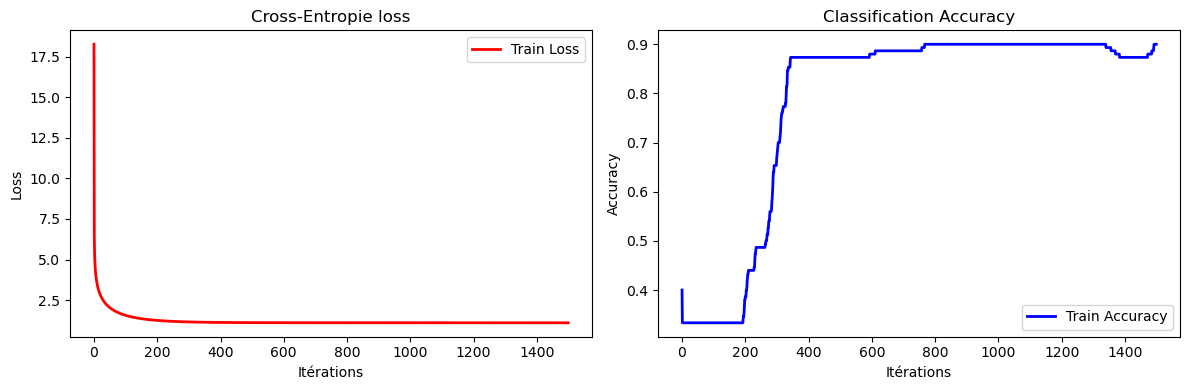

In [45]:
parametres, history = deep_neural_network(X, y_onehot, labels, hidden_layers=(256 ,128, 64),learning_rate=0.01,n_iter=1500)